# Diabetes Risk Prediction using BRFSS Health Indicators

A readable walkthrough of the reusable production pipeline. Run `python scripts/run_brfss_full_pipeline.py` before executing this notebook.

## tl;dr

The cells below load the saved, held-out results so the narrative always reflects the reproducible pipeline rather than notebook-only experimentation.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
TABLES = ROOT / 'reports' / 'brfss_final' / 'tables'
FIGURES = ROOT / 'reports' / 'brfss_final' / 'figures'
summary = json.loads((ROOT / 'reports' / 'brfss_final' / 'run_summary.json').read_text())
summary


{'dataset_shape': [253680, 22],
 'target_distribution': {'0': 213703, '1': 4631, '2': 35346},
 'original_feature_count': 21,
 'engineered_feature_count': 52,
 'selected_multiclass_model': 'XGBoost',
 'multiclass_cv_macro_f1_leader': {'model': 'ExtraTrees',
  'macro_f1': 0.44361345734232777},
 'multiclass_metrics': {'accuracy': 0.6479619993692841,
  'macro_f1': 0.4256040516897594,
  'weighted_f1': 0.718279965992946,
  'balanced_accuracy': 0.518688756858296,
  'macro_roc_auc_ovr': 0.7616251829265138,
  'macro_pr_auc_ovr': 0.46528992559730736},
 'selected_binary_model': 'XGBoost',
 'binary_cv_pr_auc_leader': {'model': 'XGBoost', 'pr_auc': 0.4160521991508584},
 'binary_metrics': {'threshold': 0.25,
  'roc_auc': 0.8285926177826042,
  'pr_auc': 0.4293533028515068,
  'recall': 0.5898995614655538,
  'precision': 0.386468952734013,
  'f1': 0.46699143289097933,
  'balanced_accuracy': 0.7191488326484111,
  'brier_score': 0.09698639065027237},
 'xgboost_multiclass_cv_macro_f1': 0.4234937879137726,

## Context & Methods

The main task predicts no diabetes, prediabetes and diabetes. A secondary binary task predicts diabetes. The test partition is held out before feature engineering, tuning, calibration or threshold selection.

### Key Assumptions

- Rows represent survey participants, but respondent IDs are unavailable.
- Exact response-profile duplicates are retained and disclosed.
- The model supports risk-screening analysis, not diagnosis.

## Data

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,1,40,1,0,0,0,0,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,0,25,1,0,0,1,0,...,0,1,3,0,0,0,0,7,6,1
2,0,1,1,1,28,0,0,0,0,1,...,1,1,5,30,30,1,0,9,4,8
3,0,1,0,1,27,0,0,0,1,1,...,1,0,2,0,0,0,0,11,3,6
4,0,1,1,1,24,0,0,0,1,1,...,1,0,2,3,0,0,0,11,5,4


,class,count,percentage,class_name
0,0,213703,0.842412,No diabetes
1,1,4631,0.018255,Prediabetes
2,2,35346,0.139333,Diabetes


,bmi_category,bmi_age_interaction,bmi_highbp_interaction,bmi_highchol_interaction,cardiometabolic_count,cardio_event_history,health_burden_score,socioeconomic_risk_count,age_bmi_interaction,age_cardiometabolic_interaction
0,3.0,360,40,40,4.0,0.0,7.1,1.0,360,36.0
1,2.0,175,0,0,0.0,0.0,3.0,1.0,175,0.0
2,2.0,252,28,28,3.0,0.0,8.0,0.0,252,27.0
3,2.0,297,27,0,1.0,0.0,2.0,1.0,297,11.0
4,1.0,264,24,24,2.0,0.0,2.1,0.0,264,22.0


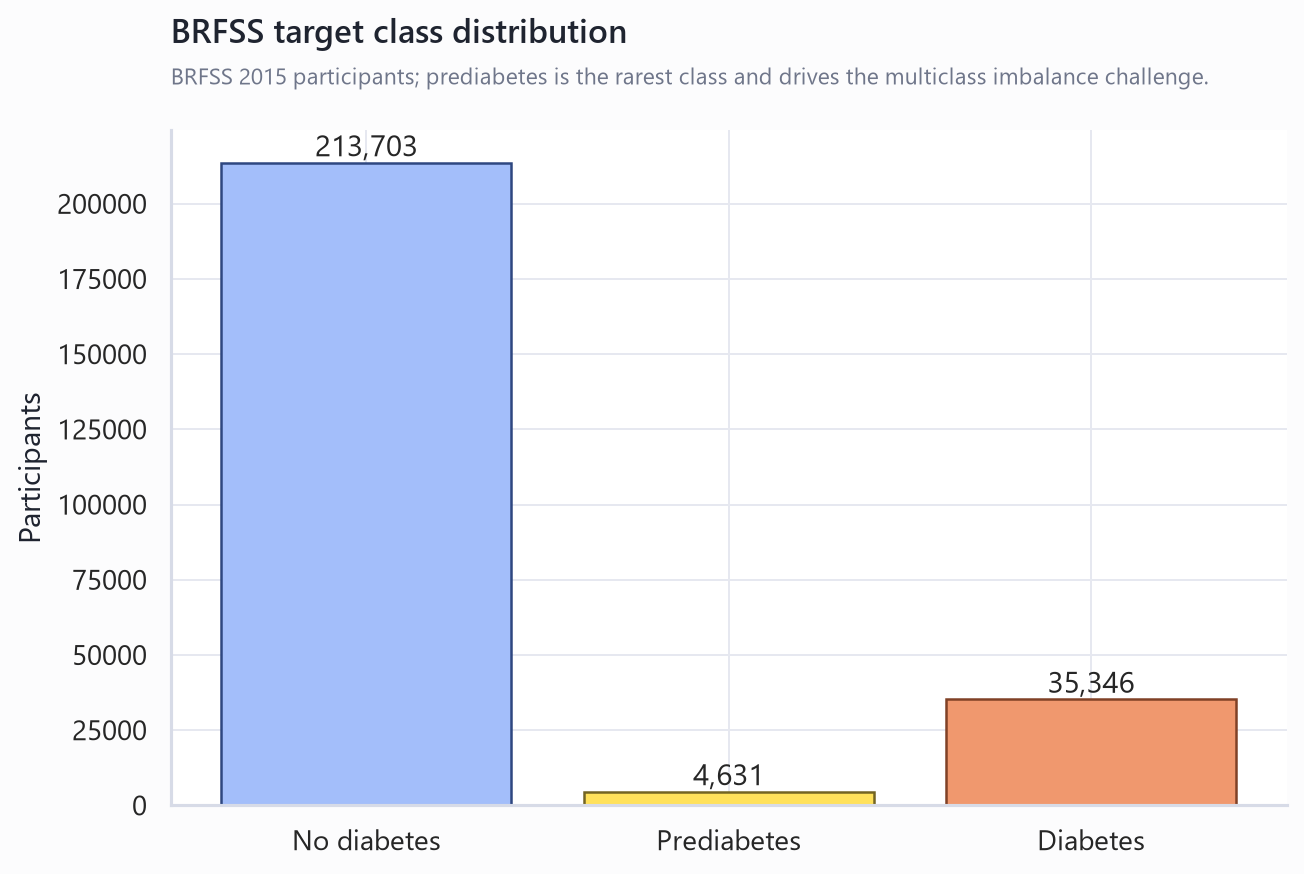

In [2]:
from brfss_diabetes.data_loading import load_brfss_data
from brfss_diabetes.feature_engineering import BRFSSFeatureEngineer

data = load_brfss_data()
display(data.head())
display(pd.read_csv(TABLES / 'class_distribution.csv'))
engineered = BRFSSFeatureEngineer().fit_transform(data.drop(columns='Diabetes_012').head(5))
display(engineered.filter(regex='bmi|cardio|health_burden|socioeconomic').head())
display(Image(filename=str(FIGURES / 'class_distribution.png')))


## Results

,model,cv_folds,macro_f1,macro_f1_std,balanced_accuracy,balanced_accuracy_std,class_0_recall,class_0_recall_std,class_1_recall,class_1_recall_std,class_2_recall,class_2_recall_std,macro_roc_auc_ovr,macro_roc_auc_ovr_std
0,ExtraTrees,3,0.4436,0.0032,0.4742,0.0052,0.8271,0.0074,0.0128,0.0083,0.5828,0.0165,0.7347,0.0046
1,Random Forest,3,0.4433,0.0039,0.4701,0.0033,0.8527,0.0058,0.0018,0.0032,0.5557,0.0102,0.7493,0.0029
2,XGBoost,3,0.4235,0.0052,0.5052,0.0048,0.6751,0.0114,0.1880,0.0083,0.6526,0.0178,0.7494,0.0018
3,Logistic Regression,3,0.4119,0.0049,0.4898,0.0114,0.6430,0.0139,0.2609,0.0297,0.5656,0.0295,0.7533,0.0086
4,DummyClassifier,3,0.3048,0.0000,0.3333,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0000


,metric,value
0,accuracy,0.6480
1,macro_f1,0.4256
2,weighted_f1,0.7183
3,balanced_accuracy,0.5187
4,macro_roc_auc_ovr,0.7616
5,macro_pr_auc_ovr,0.4653


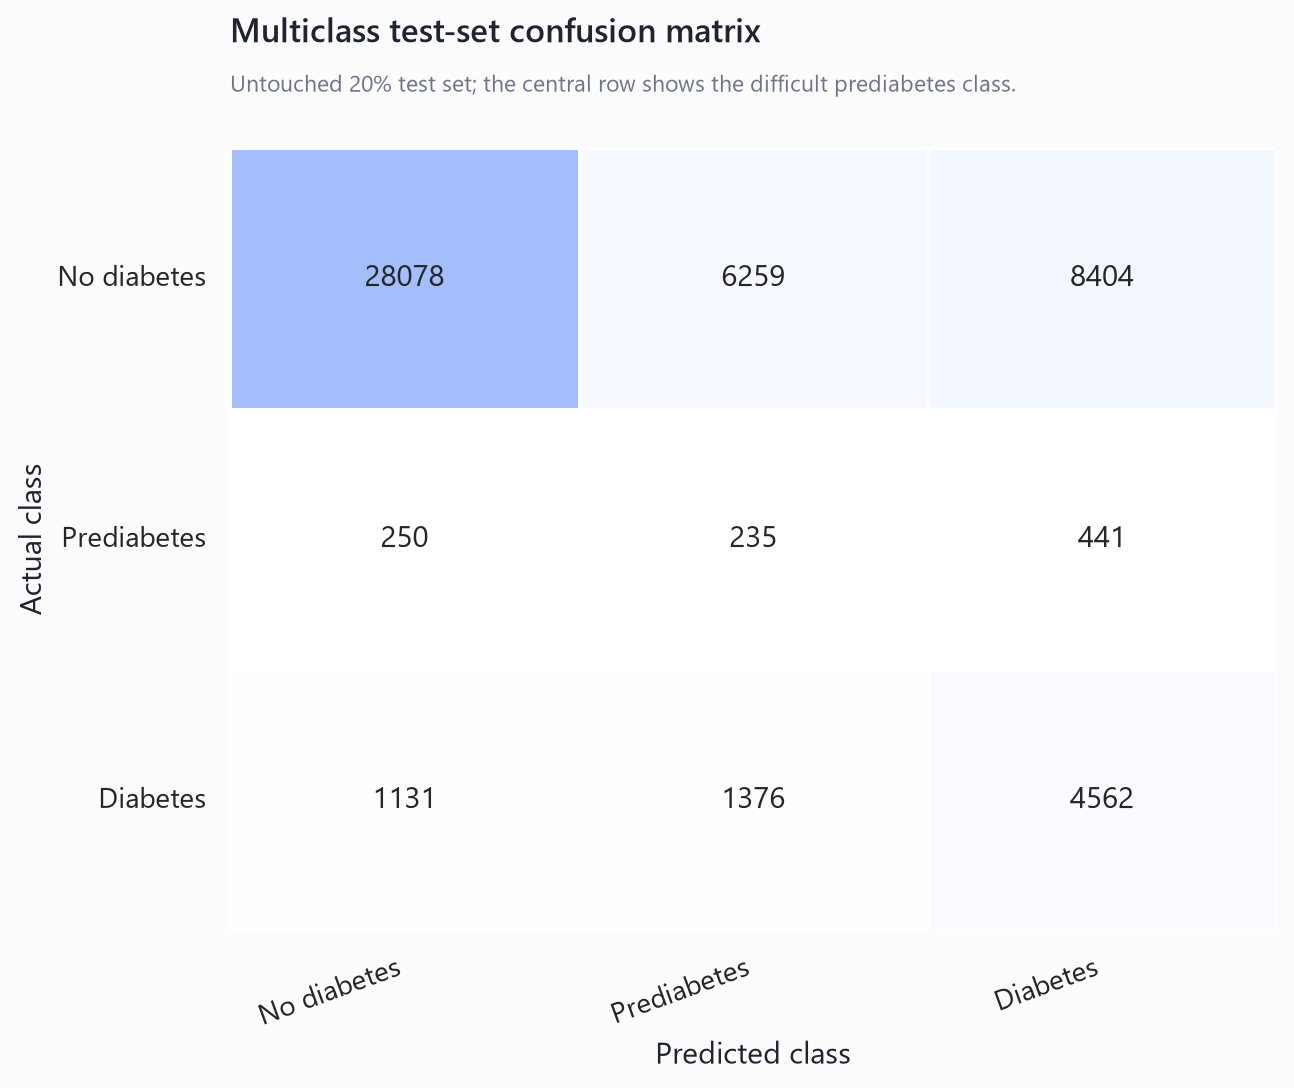

,model,cv_folds,pr_auc,pr_auc_std,roc_auc,roc_auc_std,f1,f1_std,balanced_accuracy,balanced_accuracy_std,recall,recall_std,precision,precision_std
0,XGBoost,3,0.4161,0.0075,0.8213,0.0051,0.4372,0.0053,0.7418,0.0053,0.7636,0.0097,0.3063,0.0039
1,Logistic Regression,3,0.4115,0.0126,0.8227,0.0054,0.4420,0.0018,0.7480,0.0020,0.7780,0.0076,0.3087,0.0021
2,Random Forest,3,0.3961,0.0051,0.8084,0.0049,0.4386,0.0052,0.6882,0.0015,0.5065,0.0032,0.3869,0.0101
3,ExtraTrees,3,0.3884,0.0048,0.8044,0.0028,0.4385,0.0070,0.6990,0.0047,0.5574,0.0084,0.3615,0.0072
4,DummyClassifier,3,0.1393,0.0001,0.5000,0.0000,0.0000,0.0000,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000


,metric,value
0,threshold,0.2500
1,roc_auc,0.8286
2,pr_auc,0.4294
3,recall,0.5899
4,precision,0.3865
5,f1,0.4670
6,balanced_accuracy,0.7191
7,brier_score,0.0970


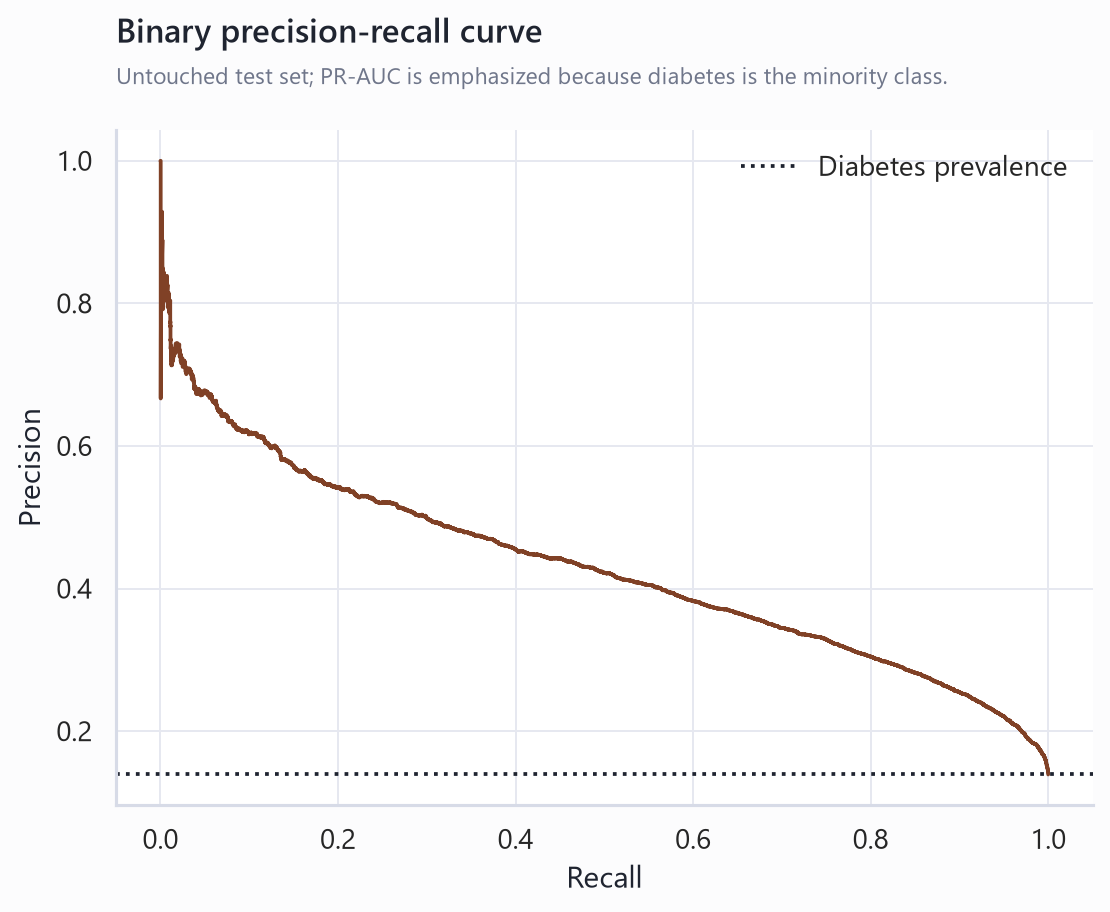

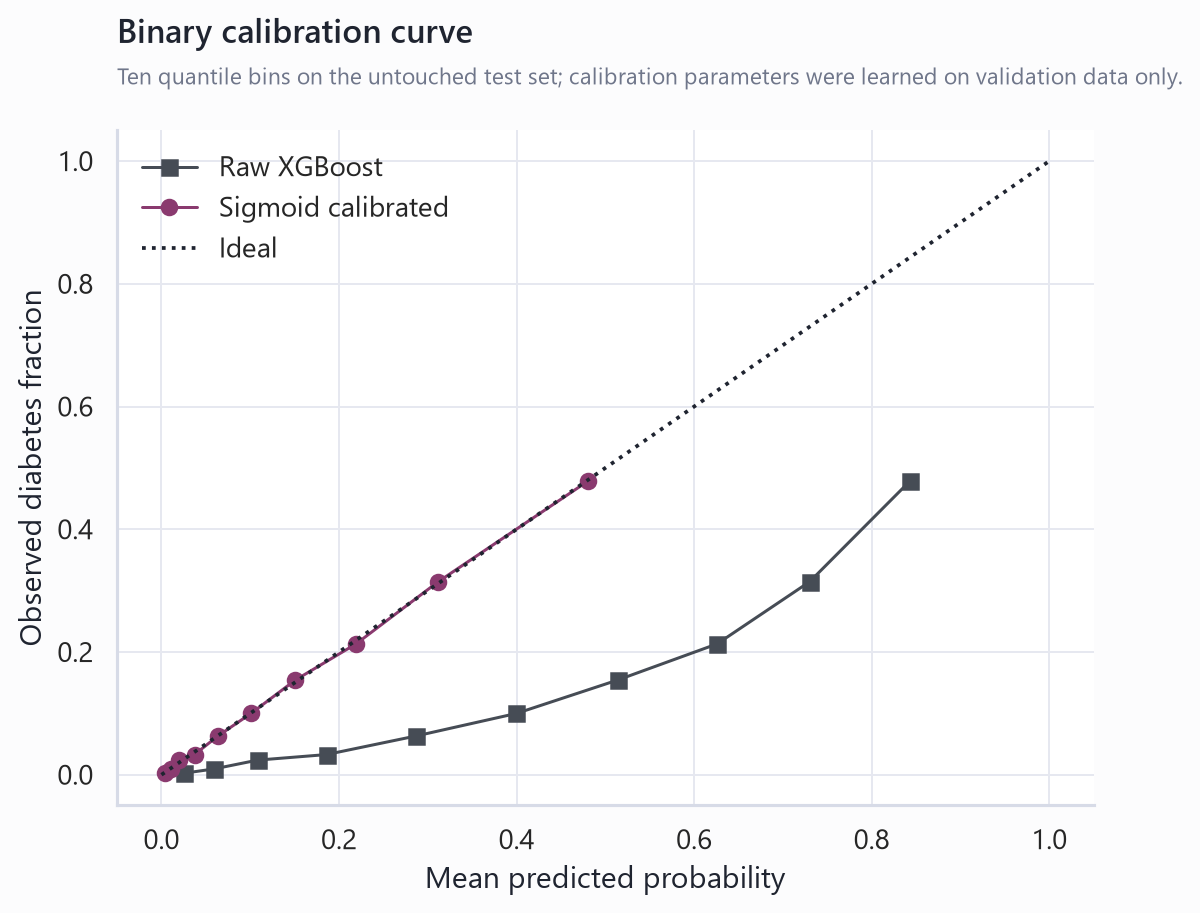

In [3]:
display(pd.read_csv(TABLES / 'model_comparison_multiclass.csv').round(4))
display(pd.read_csv(TABLES / 'final_test_metrics_multiclass.csv').round(4))
display(Image(filename=str(FIGURES / 'multiclass_confusion_matrix.png')))
display(pd.read_csv(TABLES / 'model_comparison_binary.csv').round(4))
display(pd.read_csv(TABLES / 'final_test_metrics_binary.csv').round(4))
display(Image(filename=str(FIGURES / 'binary_pr_curve.png')))
display(Image(filename=str(FIGURES / 'calibration_curve_binary.png')))


,removed_feature_family,remaining_feature_count,macro_f1,balanced_accuracy,macro_f1_drop,balanced_accuracy_drop
0,general health burden,42,0.4184,0.4809,0.0159,0.0142
1,engineered interactions,44,0.4294,0.4914,0.0049,0.0037
2,lifestyle,44,0.4307,0.4918,0.0036,0.0033
3,BMI/obesity,48,0.4310,0.4903,0.0033,0.0047
4,demographics,48,0.4317,0.4905,0.0026,0.0046
5,socioeconomic status,47,0.4335,0.4937,0.0008,0.0013
6,none (baseline),52,0.4343,0.4951,0.0000,0.0000
7,healthcare access,46,0.4349,0.4962,-0.0006,-0.0012
8,cardiometabolic history,45,0.4350,0.4963,-0.0007,-0.0012


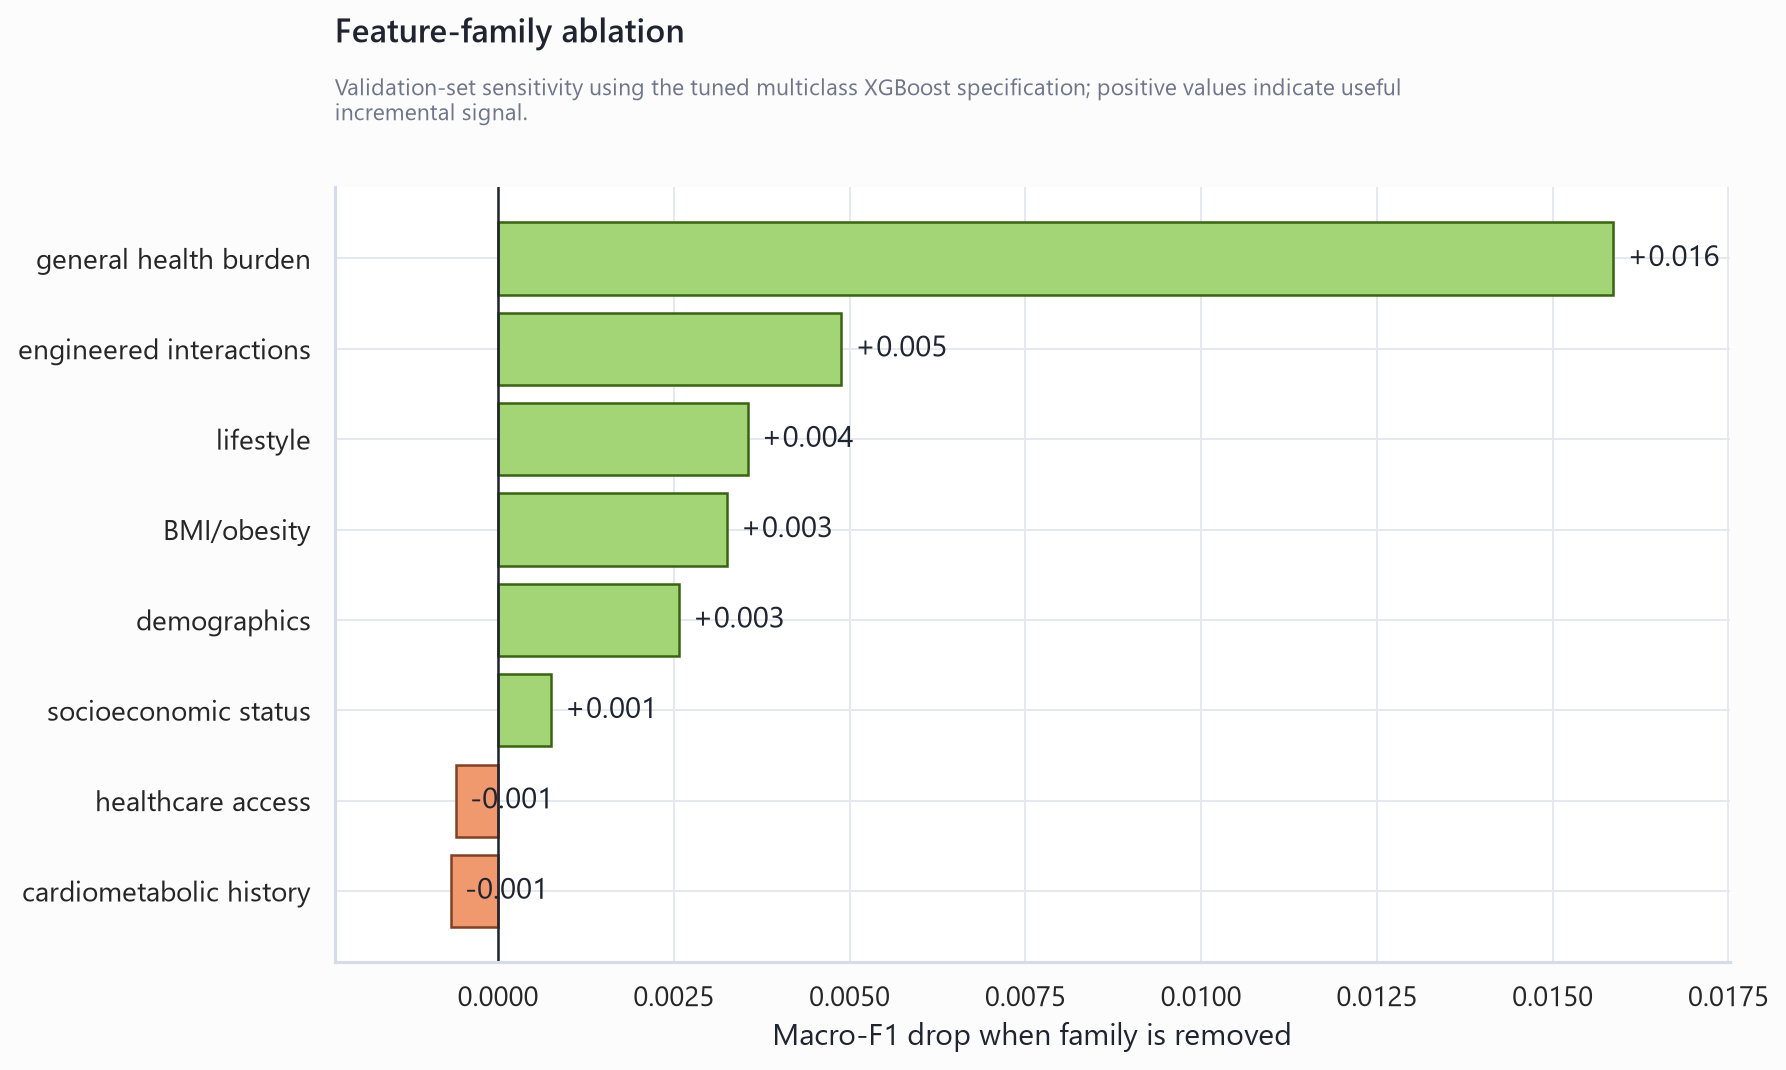

,error_type,count,percentage_of_test_set,mean_BMI,mean_Age,mean_GenHlth,mean_HighBP,mean_HighChol,mean_Income
0,diabetes_false_negative,2899,0.0571,28.4267,8.9872,2.6858,0.5254,0.4981,5.9376
1,diabetes_false_positive,6620,0.1305,32.7718,9.7323,3.5317,0.8776,0.7372,4.9707
2,prediabetes_to_no_diabetes,250,0.0049,27.2160,7.6720,2.3120,0.2680,0.3400,6.0120
3,prediabetes_to_diabetes,441,0.0087,33.2653,9.6780,3.4150,0.8662,0.7234,4.9683


,dimension,group,n,macro_f1,balanced_accuracy,class_0_recall,class_1_recall,class_2_recall
0,age_group,35-54 approx.,18711,0.4362,0.5229,0.7583,0.2500,0.5604
1,age_group,55-69 approx.,17766,0.3969,0.4911,0.5011,0.2538,0.7183
2,age_group,70+ approx.,6608,0.3202,0.4275,0.3382,0.3043,0.6401
3,age_group,18-34 approx.,7651,0.4331,0.4516,0.9452,0.1167,0.2929
4,sex,Male,22527,0.4165,0.5101,0.6285,0.2272,0.6745
5,sex,Female,28209,0.4328,0.5240,0.6791,0.2745,0.6183
6,income_group,Higher,26762,0.4302,0.5078,0.7784,0.2086,0.5365
7,income_group,Middle,16547,0.3997,0.5079,0.5406,0.3028,0.6804
8,income_group,Lower,7427,0.3804,0.4666,0.4096,0.2454,0.7449
9,education_group,College graduate,21505,0.4301,0.5154,0.7645,0.2458,0.5360


In [4]:
display(pd.read_csv(TABLES / 'feature_family_ablation.csv').round(4))
display(Image(filename=str(FIGURES / 'feature_family_ablation.png')))
display(pd.read_csv(TABLES / 'error_analysis.csv').round(4))
display(pd.read_csv(TABLES / 'subgroup_performance.csv').round(4))


## Takeaways

The official conclusions, exact metrics, limitations and CV positioning are rendered from the saved outputs below.

In [5]:
display(Markdown((ROOT / 'reports' / 'brfss_final' / 'FINAL_REPORT.md').read_text(encoding='utf-8')))


# Diabetes Risk Prediction using BRFSS Health Indicators

## Technical summary

The official project uses BRFSS 2015 survey indicators for two related screening tasks: three-class diabetes status and binary diabetes risk. The final multiclass XGBoost achieved **macro-F1 0.426**, **balanced accuracy 0.519**, prediabetes recall **0.254**, and diabetes recall **0.645** on the untouched test set. The calibrated binary model achieved **ROC-AUC 0.829**, **PR-AUC 0.429**, and recall **0.590** at threshold **0.25**.

**Model-selection conclusion:** ExtraTrees led multiclass CV macro-F1 (0.444 versus 0.423 for XGBoost). XGBoost remained the selected final multiclass model because its weighted operating point improved prediabetes recall (0.188 versus 0.013) and balanced accuracy (0.505 versus 0.474). XGBoost led the primary binary CV metric, PR-AUC (0.416). The model is suitable as a portfolio demonstration of reproducible risk-screening ML, not as a medical diagnostic system.

<!-- ROBUSTNESS_SUMMARY_START -->
**Robustness conclusion:** The official macro-F1 95% bootstrap interval is **[0.422, 0.430]**. A zero-overlap profile-grouped holdout produced macro-F1 **0.427**, close to the official **0.426**. A two-stage model reached training-only evaluation macro-F1 **0.462**, but reduced prediabetes recall and therefore remains a candidate for future external validation rather than the new official model.
<!-- ROBUSTNESS_SUMMARY_END -->

## The rare prediabetes class defines the multiclass difficulty

The dataset contains **253,680 rows**, **21 original predictors**, and no missing values. Prediabetes represents only **1.83%** of rows. Exact duplicate response rows were retained because the public extract has no respondent identifier; identical response profiles cannot be proven to be duplicate people.

| class | count | percentage | class_name |
| --- | --- | --- | --- |
| 0 | 213703 | 0.8424 | No diabetes |
| 1 | 4631 | 0.0183 | Prediabetes |
| 2 | 35346 | 0.1393 | Diabetes |

![BRFSS class distribution](figures/class_distribution.png)

This imbalance means raw accuracy would reward predicting the majority class. Macro-F1, balanced accuracy and class-wise recall therefore governed model selection.

## Multiclass and binary tasks answer different screening questions

The official task predicts `Diabetes_012`: 0 for no diabetes, 1 for prediabetes and 2 for diabetes. The secondary task predicts diabetes versus no diabetes/prediabetes. The multiclass task preserves the clinically meaningful intermediate group; the binary task provides a more separable benchmark and supports probability calibration and operating-threshold analysis.

## Data validation found no missingness but identified profile duplication

All expected columns were available and all coded ranges passed validation. There were 23,899 exact duplicate rows. Because no respondent key is present, rows were retained and split using reproducible stratification. This can make performance optimistic when identical profiles appear across partitions and is documented as a limitation.

## Domain features expanded the model from 21 to 52 predictors

Feature engineering retained all original variables and added BMI categories, cardiometabolic burden, lifestyle risk, healthcare access, general-health burden, socioeconomic risk and interactions. Every transformation is deterministic and occurs inside the fitted pipeline.

The highest-impact families in validation ablation were: **general health burden, engineered interactions, lifestyle**.

![Feature-family ablation](figures/feature_family_ablation.png)

Positive drops show that removing the family reduced macro-F1. Small or negative drops indicate redundancy or weak incremental signal, not clinical irrelevance.

## Leakage-safe preprocessing and imbalance handling

The untouched test set was split before feature engineering, imputation, scaling, tuning, calibration or threshold selection. Linear models used median imputation, scaling and one-hot encoding for engineered ordinal categories. Tree models retained ordinal codes with median imputation. Multiclass XGBoost used training-fold balanced sample weights; synthetic oversampling was not selected because the coded survey feature space and calibration objective made class weighting the lower-risk default.

## XGBoost was tuned against strong baselines

| model | cv_folds | macro_f1 | macro_f1_std | balanced_accuracy | balanced_accuracy_std | class_0_recall | class_0_recall_std | class_1_recall | class_1_recall_std | class_2_recall | class_2_recall_std | macro_roc_auc_ovr | macro_roc_auc_ovr_std |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| ExtraTrees | 3 | 0.4436 | 0.0032 | 0.4742 | 0.0052 | 0.8271 | 0.0074 | 0.0128 | 0.0083 | 0.5828 | 0.0165 | 0.7347 | 0.0046 |
| Random Forest | 3 | 0.4433 | 0.0039 | 0.4701 | 0.0033 | 0.8527 | 0.0058 | 0.0018 | 0.0032 | 0.5557 | 0.0102 | 0.7493 | 0.0029 |
| XGBoost | 3 | 0.4235 | 0.0052 | 0.5052 | 0.0048 | 0.6751 | 0.0114 | 0.1880 | 0.0083 | 0.6526 | 0.0178 | 0.7494 | 0.0018 |
| Logistic Regression | 3 | 0.4119 | 0.0049 | 0.4898 | 0.0114 | 0.6430 | 0.0139 | 0.2609 | 0.0297 | 0.5656 | 0.0295 | 0.7533 | 0.0086 |
| DummyClassifier | 3 | 0.3048 | 0.0000 | 0.3333 | 0.0000 | 1.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.5000 | 0.0000 |

![Multiclass model comparison](figures/model_comparison_multiclass.png)

| model | cv_folds | pr_auc | pr_auc_std | roc_auc | roc_auc_std | f1 | f1_std | balanced_accuracy | balanced_accuracy_std | recall | recall_std | precision | precision_std |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| XGBoost | 3 | 0.4161 | 0.0075 | 0.8213 | 0.0051 | 0.4372 | 0.0053 | 0.7418 | 0.0053 | 0.7636 | 0.0097 | 0.3063 | 0.0039 |
| Logistic Regression | 3 | 0.4115 | 0.0126 | 0.8227 | 0.0054 | 0.4420 | 0.0018 | 0.7480 | 0.0020 | 0.7780 | 0.0076 | 0.3087 | 0.0021 |
| Random Forest | 3 | 0.3961 | 0.0051 | 0.8084 | 0.0049 | 0.4386 | 0.0052 | 0.6882 | 0.0015 | 0.5065 | 0.0032 | 0.3869 | 0.0101 |
| ExtraTrees | 3 | 0.3884 | 0.0048 | 0.8044 | 0.0028 | 0.4385 | 0.0070 | 0.6990 | 0.0047 | 0.5574 | 0.0084 | 0.3615 | 0.0072 |
| DummyClassifier | 3 | 0.1393 | 0.0001 | 0.5000 | 0.0000 | 0.0000 | 0.0000 | 0.5000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 |

![Binary model comparison](figures/model_comparison_binary.png)

Logistic regression regularization, Random Forest structure and XGBoost parameters were tuned using training-only cross-validation. XGBoost tuning covered estimators, depth, learning rate, subsampling, column sampling, child weight, gamma and L1/L2 regularization. Selected multiclass XGBoost parameters: `{'colsample_bytree': 0.7713532627589614, 'gamma': 0.4563633644393066, 'learning_rate': 0.061738558891618764, 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 228, 'reg_alpha': 0.012563152773938664, 'reg_lambda': 1.5151324184839015, 'subsample': 0.7330663856998123}`. Selected binary XGBoost parameters: `{'colsample_bytree': 0.9926515452756086, 'gamma': 0.34915701064545634, 'learning_rate': 0.029223394319260826, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 287, 'reg_alpha': 0.011400863701127324, 'reg_lambda': 2.584093506411774, 'subsample': 0.7330061155615993, 'scale_pos_weight': 6.176998974431517}`.

## Final multiclass errors concentrate around prediabetes

| metric | value |
| --- | --- |
| accuracy | 0.6480 |
| macro_f1 | 0.4256 |
| weighted_f1 | 0.7183 |
| balanced_accuracy | 0.5187 |
| macro_roc_auc_ovr | 0.7616 |
| macro_pr_auc_ovr | 0.4653 |

| class | precision | recall | f1-score | support |
| --- | --- | --- | --- | --- |
| No diabetes | 0.9531 | 0.6569 | 0.7778 | 42741.0000 |
| Prediabetes | 0.0299 | 0.2538 | 0.0534 | 926.0000 |
| Diabetes | 0.3403 | 0.6454 | 0.4456 | 7069.0000 |
| accuracy | 0.6480 | 0.6480 | 0.6480 | 0.6480 |
| macro avg | 0.4411 | 0.5187 | 0.4256 | 50736.0000 |
| weighted avg | 0.8509 | 0.6480 | 0.7183 | 50736.0000 |

![Multiclass confusion matrix](figures/multiclass_confusion_matrix.png)

Prediabetes has weaker separability than diabetes because it is rare and BRFSS indicators are survey/self-reported rather than glycemic biomarkers. Confusions with both no diabetes and diabetes are therefore reported directly rather than hidden by aggregate accuracy.

## The binary task supports calibrated risk screening

| metric | value |
| --- | --- |
| threshold | 0.2500 |
| roc_auc | 0.8286 |
| pr_auc | 0.4294 |
| recall | 0.5899 |
| precision | 0.3865 |
| f1 | 0.4670 |
| balanced_accuracy | 0.7191 |
| brier_score | 0.0970 |

| class | precision | recall | f1-score | support |
| --- | --- | --- | --- | --- |
| No diabetes | 0.9274 | 0.8484 | 0.8862 | 43667.0000 |
| Diabetes | 0.3865 | 0.5899 | 0.4670 | 7069.0000 |
| accuracy | 0.8124 | 0.8124 | 0.8124 | 0.8124 |
| macro avg | 0.6569 | 0.7191 | 0.6766 | 50736.0000 |
| weighted avg | 0.8521 | 0.8124 | 0.8278 | 50736.0000 |

![Binary precision-recall curve](figures/binary_pr_curve.png)

![Binary calibration curve](figures/calibration_curve_binary.png)

The sigmoid calibrator and operating threshold were learned from validation probabilities only. The test set was used once for the final metric readout.

## Threshold choice changes the screening operating point

| threshold | precision | recall | f1 | balanced_accuracy | predicted_positive_rate | meets_minimum_precision | selection |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 0.1100 | 0.2779 | 0.8510 | 0.4190 | 0.7465 | 0.4267 | False | \|high_recall |
| 0.1700 | 0.3315 | 0.7515 | 0.4601 | 0.7531 | 0.3159 | False | \|balanced_precision_recall |
| 0.2000 | 0.3530 | 0.6893 | 0.4669 | 0.7424 | 0.2721 | True | \|minimum_precision |
| 0.2500 | 0.3939 | 0.5962 | 0.4744 | 0.7238 | 0.2109 | True | max_f1 |

![Threshold trade-off](figures/threshold_precision_recall_tradeoff.png)

The saved binary report uses the validation-selected max-F1 threshold. Other rows support high-recall or minimum-precision operating points without pretending one threshold is universally correct.

The multiclass high-risk sensitivity analysis defines high risk as class 1 or 2:

| threshold | high_risk_precision | high_risk_recall | f1 | balanced_accuracy | predicted_positive_rate | meets_minimum_precision | selection |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 0.2100 | 0.2011 | 0.9808 | 0.3337 | 0.6259 | 0.7687 | True | \|minimum_precision |
| 0.5900 | 0.2965 | 0.8551 | 0.4403 | 0.7378 | 0.4545 | True | \|high_recall |
| 0.6400 | 0.3196 | 0.8157 | 0.4592 | 0.7454 | 0.4022 | True | \|balanced_precision_recall |
| 0.7800 | 0.4144 | 0.5943 | 0.4884 | 0.7186 | 0.2260 | True | max_f1 |
| 0.8672 | 0.5097 | 0.3235 |  |  | 0.1000 | True | top_10_percent |
| 0.7988 | 0.4327 | 0.5493 |  |  | 0.2000 | True | top_20_percent |
| 0.7244 | 0.3686 | 0.7017 |  |  | 0.3000 | True | top_30_percent |
| 0.6424 | 0.3204 | 0.8134 |  |  | 0.4000 | True | top_40_percent |
| 0.5450 | 0.2793 | 0.8862 |  |  | 0.5000 | True | top_50_percent |

## Multiple interpretation methods agree on the main signal families

![XGBoost feature importance](figures/top_feature_importance_xgboost.png)

![Permutation importance](figures/permutation_importance_top20.png)

Built-in importance, held-out permutation importance and family ablation were all used. These methods describe predictive contribution; none establishes causal or clinical effect.

Top built-in features:

| feature | importance | feature_family |
| --- | --- | --- |
| cardiometabolic_count | 0.1034 | cardiometabolic history |
| age_cardiometabolic_interaction | 0.0765 | engineered interactions |
| GenHlth | 0.0509 | general health burden |
| poor_general_health_flag | 0.0280 | general health burden |
| bmi_age_interaction | 0.0224 | engineered interactions |
| health_burden_score | 0.0218 | general health burden |
| bmi_highbp_interaction | 0.0217 | engineered interactions |
| HighBP | 0.0212 | cardiometabolic history |
| older_adult_flag | 0.0197 | demographics |
| HvyAlcoholConsump | 0.0195 | lifestyle |
| bmi_category | 0.0186 | BMI/obesity |
| CholCheck | 0.0185 | healthcare access |
| cholcheck_with_highchol_flag | 0.0183 | healthcare access |
| age_band | 0.0178 | demographics |
| low_education_flag | 0.0177 | socioeconomic status |

Top permutation features:

| feature | importance_mean | importance_std | feature_family |
| --- | --- | --- | --- |
| HvyAlcoholConsump | 0.0024 | 0.0015 | lifestyle |
| Sex | 0.0023 | 0.0020 | demographics |
| bmi_highbp_interaction | 0.0016 | 0.0010 | engineered interactions |
| PhysActivity | 0.0006 | 0.0008 | lifestyle |
| PhysHlth | 0.0006 | 0.0001 | general health burden |
| poor_general_health_flag | 0.0004 | 0.0004 | general health burden |
| Smoker | 0.0004 | 0.0004 | lifestyle |
| CholCheck | 0.0003 | 0.0004 | healthcare access |
| Stroke | 0.0003 | 0.0003 | cardiometabolic history |
| socioeconomic_risk_count | 0.0003 | 0.0004 | socioeconomic status |
| obese_flag | 0.0002 | 0.0001 | BMI/obesity |
| smoking_inactivity_combo | 0.0002 | 0.0006 | engineered interactions |
| low_income_flag | 0.0001 | 0.0000 | socioeconomic status |
| overweight_or_obese_flag | -0.0000 | 0.0000 | BMI/obesity |
| healthcare_access_barrier | -0.0000 | 0.0003 | healthcare access |

## Error and subgroup diagnostics expose where the model is weakest

| error_type | count | percentage_of_test_set | mean_BMI | mean_Age | mean_GenHlth | mean_HighBP | mean_HighChol | mean_Income |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| diabetes_false_negative | 2899 | 0.0571 | 28.4267 | 8.9872 | 2.6858 | 0.5254 | 0.4981 | 5.9376 |
| diabetes_false_positive | 6620 | 0.1305 | 32.7718 | 9.7323 | 3.5317 | 0.8776 | 0.7372 | 4.9707 |
| prediabetes_to_no_diabetes | 250 | 0.0049 | 27.2160 | 7.6720 | 2.3120 | 0.2680 | 0.3400 | 6.0120 |
| prediabetes_to_diabetes | 441 | 0.0087 | 33.2653 | 9.6780 | 3.4150 | 0.8662 | 0.7234 | 4.9683 |

| dimension | group | n | macro_f1 | balanced_accuracy | class_0_recall | class_1_recall | class_2_recall |
| --- | --- | --- | --- | --- | --- | --- | --- |
| age_group | 35-54 approx. | 18711 | 0.4362 | 0.5229 | 0.7583 | 0.2500 | 0.5604 |
| age_group | 55-69 approx. | 17766 | 0.3969 | 0.4911 | 0.5011 | 0.2538 | 0.7183 |
| age_group | 70+ approx. | 6608 | 0.3202 | 0.4275 | 0.3382 | 0.3043 | 0.6401 |
| age_group | 18-34 approx. | 7651 | 0.4331 | 0.4516 | 0.9452 | 0.1167 | 0.2929 |
| sex | Male | 22527 | 0.4165 | 0.5101 | 0.6285 | 0.2272 | 0.6745 |
| sex | Female | 28209 | 0.4328 | 0.5240 | 0.6791 | 0.2745 | 0.6183 |
| income_group | Higher | 26762 | 0.4302 | 0.5078 | 0.7784 | 0.2086 | 0.5365 |
| income_group | Middle | 16547 | 0.3997 | 0.5079 | 0.5406 | 0.3028 | 0.6804 |
| income_group | Lower | 7427 | 0.3804 | 0.4666 | 0.4096 | 0.2454 | 0.7449 |
| education_group | College graduate | 21505 | 0.4301 | 0.5154 | 0.7645 | 0.2458 | 0.5360 |
| education_group | Some college | 26509 | 0.4127 | 0.5088 | 0.5876 | 0.2538 | 0.6851 |
| education_group | High school or lower | 2722 | 0.3691 | 0.4543 | 0.3658 | 0.2762 | 0.7210 |

Subgroup diagnostics are descriptive checks by age, sex, income and education. They are not a fairness certification because BRFSS coding, sample composition and outcome quality can differ across groups.

<!-- ROBUSTNESS_ANALYSIS_START -->
## Robustness analysis quantifies uncertainty and tests alternative ML designs

The official holdout estimates are now accompanied by stratified bootstrap intervals. Multiclass macro-F1 was **0.426** with a 95% interval of **[0.422, 0.430]**. Binary ROC-AUC was **0.829** with a 95% interval of **[0.824, 0.833]**. These intervals describe sampling uncertainty in the fixed test set; they do not cover temporal or population shift.

![Bootstrap confidence intervals](figures/bootstrap_confidence_intervals.png)

| metric | estimate | ci_lower_95 | ci_upper_95 | bootstrap_repetitions |
| --- | --- | --- | --- | --- |
| multiclass_macro_f1 | 0.4256 | 0.4218 | 0.4296 | 1000 |
| multiclass_balanced_accuracy | 0.5187 | 0.5086 | 0.5290 | 1000 |
| prediabetes_recall | 0.2538 | 0.2257 | 0.2819 | 1000 |
| diabetes_recall | 0.6454 | 0.6329 | 0.6564 | 1000 |
| multiclass_macro_roc_auc_ovr | 0.7616 | 0.7557 | 0.7681 | 1000 |
| binary_roc_auc | 0.8286 | 0.8237 | 0.8334 | 1000 |
| binary_pr_auc | 0.4294 | 0.4194 | 0.4417 | 1000 |
| binary_recall | 0.5899 | 0.5777 | 0.6012 | 1000 |
| binary_precision | 0.3865 | 0.3798 | 0.3935 | 1000 |
| binary_f1 | 0.4670 | 0.4590 | 0.4749 | 1000 |

### Repeated CV confirms the model-ranking trade-off

Five-fold cross-validation repeated across three seeds confirms that no single model dominates every objective. ExtraTrees remains competitive on macro-F1, while weighted XGBoost retains materially stronger prediabetes recall. The comparison is based only on a stratified training sample and does not reuse the official test set for selection.

![Repeated CV comparison](figures/repeated_cv_model_comparison.png)

| model | folds | macro_f1_mean | macro_f1_std | balanced_accuracy_mean | class_1_recall_mean | class_2_recall_mean | macro_roc_auc_ovr_mean |
| --- | --- | --- | --- | --- | --- | --- | --- |
| ExtraTrees | 15 | 0.4459 | 0.0054 | 0.4766 | 0.0280 | 0.5792 | 0.7370 |
| XGBoost — engineered features | 15 | 0.4338 | 0.0048 | 0.4956 | 0.0821 | 0.6721 | 0.7452 |
| XGBoost — original features | 15 | 0.4311 | 0.0043 | 0.4991 | 0.1156 | 0.6670 | 0.7452 |
| Logistic Regression | 15 | 0.4153 | 0.0053 | 0.4998 | 0.2823 | 0.5738 | 0.7589 |

### Engineered features provide limited incremental average performance

Using identical repeated-CV folds, the original-plus-engineered specification produced mean macro-F1 **0.434**, versus **0.431** for original features alone. The result should be interpreted as an ablation finding: engineered variables improve transparency and specific interactions, but they do not guarantee a large aggregate score increase.

| configuration | folds | macro_f1_mean | macro_f1_std | balanced_accuracy_mean | class_1_recall_mean | class_2_recall_mean | macro_roc_auc_ovr_mean | paired_macro_f1_difference_mean | paired_macro_f1_difference_std |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Original + engineered features | 15 | 0.4338 | 0.0048 | 0.4956 | 0.0821 | 0.6721 | 0.7452 | 0.0027 | 0.0041 |
| Original features only | 15 | 0.4311 | 0.0043 | 0.4991 | 0.1156 | 0.6670 | 0.7452 |  |  |

### Grouping identical profiles changes the evaluation population

The profile-grouped split had zero predictor-profile overlap and produced macro-F1 **0.427**, compared with **0.426** on the official random holdout. Because the grouped and random test populations differ, this is a robustness sensitivity rather than a paired estimate of leakage bias.

![Grouped split comparison](figures/grouped_profile_split_comparison.png)

| split_design | metric | value | test_rows | profile_overlap_count |
| --- | --- | --- | --- | --- |
| Official random holdout | accuracy | 0.6480 | 50736 | 5104 |
| Official random holdout | macro_f1 | 0.4256 | 50736 | 5104 |
| Official random holdout | balanced_accuracy | 0.5187 | 50736 | 5104 |
| Official random holdout | class_1_recall | 0.2538 | 50736 | 5104 |
| Official random holdout | class_2_recall | 0.6454 | 50736 | 5104 |
| Official random holdout | macro_roc_auc_ovr | 0.7616 | 50736 | 5104 |
| Profile-grouped holdout | accuracy | 0.6488 | 50735 | 0 |
| Profile-grouped holdout | macro_f1 | 0.4265 | 50735 | 0 |
| Profile-grouped holdout | balanced_accuracy | 0.5231 | 50735 | 0 |
| Profile-grouped holdout | class_1_recall | 0.2592 | 50735 | 0 |
| Profile-grouped holdout | class_2_recall | 0.6538 | 50735 | 0 |
| Profile-grouped holdout | macro_roc_auc_ovr | 0.7705 | 50735 | 0 |

### Advanced strategies did not automatically solve prediabetes separation

The strategy evaluation split was created entirely inside the original training partition. The best validation-only strategy was **Two-stage high-risk XGBoost**, with macro-F1 **0.462**, versus **0.428** for the weighted XGBoost baseline. Probability multipliers selected class-1 factor **0.50** and class-2 factor **0.60**. These are model-development results, not new independent test claims.

![Advanced strategy comparison](figures/advanced_multiclass_strategy_comparison.png)

| strategy | accuracy | macro_f1 | balanced_accuracy | class_1_recall | class_1_precision | class_2_recall | macro_roc_auc_ovr | multiclass_log_loss | multiclass_ece |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Two-stage high-risk XGBoost | 0.7765 | 0.4619 | 0.4934 | 0.0917 | 0.0388 | 0.5614 | 0.7816 | 0.6200 | 0.1087 |
| Class-specific probability multipliers | 0.7714 | 0.4592 | 0.4995 | 0.0540 | 0.0372 | 0.6352 | 0.7704 | 0.6171 | 0.0985 |
| Custom class weights | 0.7399 | 0.4515 | 0.5100 | 0.0791 | 0.0373 | 0.6880 | 0.7696 | 0.6758 | 0.0887 |
| OOF Logistic + ExtraTrees + XGBoost ensemble | 0.7267 | 0.4432 | 0.5058 | 0.0665 | 0.0285 | 0.7064 | 0.7658 | 0.7298 | 0.1148 |
| Weighted XGBoost baseline | 0.6554 | 0.4276 | 0.5224 | 0.2338 | 0.0320 | 0.6715 | 0.7639 | 0.8000 | 0.0698 |
| Ordinal cumulative XGBoost | 0.7100 | 0.4170 | 0.5028 | 0.0000 | 0.0000 | 0.7975 | 0.7123 | 0.7223 | 0.0585 |
| Multiclass probability calibration | 0.8489 | 0.3936 | 0.3840 | 0.0000 | 0.0000 | 0.1728 | 0.7804 | 0.3941 | 0.0046 |

The comparison includes class-specific probability adjustment, custom class weighting, multinomial probability calibration, ordinal cumulative models, a two-stage high-risk model, and an out-of-fold Logistic/ExtraTrees/XGBoost ensemble. The two-stage model improved macro-F1 mainly by recovering majority-class precision; its prediabetes recall remained below the weighted baseline. It is therefore a candidate operating design, not an unconditional replacement.

### Calibration, SMOTE-NC and paired statistical comparisons

Multiclass calibration was evaluated using log loss, multiclass Brier score and expected calibration error. Calibration sharply improved probability quality but collapsed prediabetes recall to zero at the default argmax rule, demonstrating that calibrated probabilities still require a separate decision policy. Moderate SMOTE-NC was run inside each CV training fold and compared with balanced sample weights; it reduced macro-F1, balanced accuracy and diabetes recall, so class weighting remains the preferred imbalance treatment.

| probability | macro_f1 | balanced_accuracy | class_1_recall | class_2_recall | multiclass_log_loss | multiclass_brier_score | multiclass_ece |
| --- | --- | --- | --- | --- | --- | --- | --- |
| Raw weighted XGBoost | 0.4276 | 0.5224 | 0.2338 | 0.6715 | 0.8000 | 0.4518 | 0.0698 |
| Multinomial log-probability calibration | 0.3936 | 0.3840 | 0.0000 | 0.1728 | 0.3941 | 0.2207 | 0.0046 |

| strategy | folds | macro_f1_mean | macro_f1_std | balanced_accuracy_mean | class_1_recall_mean | class_1_precision_mean | class_2_recall_mean | multiclass_log_loss_mean |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Balanced sample weights | 3 | 0.4389 | 0.0040 | 0.4857 | 0.0328 | 0.0183 | 0.6491 | 0.5924 |
| Moderate SMOTE-NC | 3 | 0.4303 | 0.0073 | 0.4193 | 0.0028 | 0.0667 | 0.3082 | 0.4182 |

Paired bootstrap intervals compare models on the same observations. An interval crossing zero indicates that the available test set does not establish a clear difference for that metric. Exact McNemar tests compare paired correctness, but statistical significance should not be confused with practical value in a dataset this large.

| metric | model_a | model_b | difference_a_minus_b | ci_lower_95 | ci_upper_95 | probability_difference_positive | bootstrap_repetitions |
| --- | --- | --- | --- | --- | --- | --- | --- |
| multiclass_macro_f1 | Weighted XGBoost | ExtraTrees | -0.0197 | -0.0239 | -0.0156 | 0.0000 | 1000 |
| multiclass_balanced_accuracy | Weighted XGBoost | ExtraTrees | 0.0220 | 0.0122 | 0.0321 | 1.0000 | 1000 |
| prediabetes_recall | Weighted XGBoost | ExtraTrees | 0.1836 | 0.1555 | 0.2127 | 1.0000 | 1000 |
| binary_roc_auc | Calibrated XGBoost | Logistic Regression | 0.0048 | 0.0037 | 0.0059 | 1.0000 | 1000 |
| binary_pr_auc | Calibrated XGBoost | Logistic Regression | 0.0173 | 0.0126 | 0.0220 | 1.0000 | 1000 |

| test | model_a | model_b | a_correct_b_wrong | a_wrong_b_correct | discordant_pairs | p_value | p_value_display |
| --- | --- | --- | --- | --- | --- | --- | --- |
| exact_mcnemar | Weighted XGBoost | ExtraTrees | 1152 | 5748 | 6900 | 0.0000 | <1e-300 |
| exact_mcnemar | Calibrated XGBoost | Threshold-tuned Logistic Regression | 1381 | 674 | 2055 | 0.0000 | 8.931e-56 |

Detailed selection surfaces are saved in `multiclass_probability_threshold_tuning.csv` and `class_weight_sensitivity.csv`:

| class_0_multiplier | class_1_multiplier | class_2_multiplier | accuracy | macro_f1 | balanced_accuracy | class_0_recall | class_1_recall | class_2_recall | class_0_precision | class_1_precision | class_2_precision | selection |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 1.0000 | 0.5000 | 0.6000 | 0.7717 | 0.4591 | 0.4965 | 0.8136 | 0.0647 | 0.6110 | 0.9240 | 0.0426 | 0.3695 | max_macro_f1 |
| 1.0000 | 3.0000 | 0.6000 | 0.3770 | 0.2531 | 0.4614 | 0.4164 | 0.8975 | 0.0702 | 0.9767 | 0.0263 | 0.5408 | \|max_prediabetes_recall |

| class_1_multiplier | class_2_multiplier | accuracy | macro_f1 | balanced_accuracy | class_0_recall | class_1_recall | class_2_recall | class_0_precision | class_1_precision | class_2_precision | macro_roc_auc_ovr | multiclass_log_loss | multiclass_brier_score | multiclass_ece | selection |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 0.6000 | 0.7500 | 0.7477 | 0.4500 | 0.5001 | 0.7786 | 0.0719 | 0.6497 | 0.9308 | 0.0395 | 0.3454 | 0.7627 | 0.6149 | 0.3475 | 0.0526 | max_macro_f1 |
| 0.8000 | 0.7500 | 0.7329 | 0.4478 | 0.5024 | 0.7644 | 0.1205 | 0.6223 | 0.9333 | 0.0350 | 0.3507 | 0.7607 | 0.6449 | 0.3639 | 0.0496 |  |
| 1.0000 | 0.7500 | 0.7154 | 0.4417 | 0.5001 | 0.7496 | 0.1709 | 0.5799 | 0.9349 | 0.0329 | 0.3518 | 0.7593 | 0.6724 | 0.3796 | 0.0508 |  |
| 0.6000 | 1.0000 | 0.7200 | 0.4366 | 0.5043 | 0.7326 | 0.0486 | 0.7317 | 0.9410 | 0.0396 | 0.3168 | 0.7595 | 0.6549 | 0.3759 | 0.0267 |  |
| 1.0000 | 1.0000 | 0.6976 | 0.4365 | 0.5126 | 0.7116 | 0.1403 | 0.6860 | 0.9435 | 0.0368 | 0.3238 | 0.7589 | 0.7094 | 0.4026 | 0.0376 |  |
| 0.8000 | 1.0000 | 0.7074 | 0.4365 | 0.5076 | 0.7202 | 0.0917 | 0.7110 | 0.9417 | 0.0372 | 0.3188 | 0.7589 | 0.6844 | 0.3898 | 0.0328 |  |
| 1.2500 | 0.7500 | 0.6958 | 0.4363 | 0.4999 | 0.7321 | 0.2302 | 0.5375 | 0.9377 | 0.0312 | 0.3605 | 0.7582 | 0.7014 | 0.3973 | 0.0493 |  |
| 1.2500 | 1.0000 | 0.6814 | 0.4318 | 0.5120 | 0.6976 | 0.1906 | 0.6478 | 0.9452 | 0.0340 | 0.3272 | 0.7548 | 0.7380 | 0.4184 | 0.0407 |  |
<!-- ROBUSTNESS_ANALYSIS_END -->

## Limitations and robustness checks

- BRFSS is survey and self-reported data; labels and predictors may contain recall or reporting error.
- The model is a risk-screening exercise, not a diagnostic medical system.
- Prediabetes is difficult because of severe class imbalance and weak survey-feature separability.
- Exact profile duplicates were retained because respondent identifiers are absent. A profile-grouped sensitivity split produced similar aggregate performance with zero profile overlap, but it is still only internal validation.
- The single 2015 extract provides internal holdout validation, not temporal or external validation.
- Feature importance is associative and should not be interpreted as clinical causality.
- Calibration and threshold choices may shift under a different population prevalence.

## Recommended next steps

Use the BRFSS project as the official CV project. Position the contribution around leakage-safe pipeline design, domain features, imbalance-aware evaluation, repeated validation, bootstrap uncertainty, calibration, threshold selection and honest prediabetes limitations. Treat the two-stage model as the leading future candidate until it is confirmed on a fresh external or temporal test set. Keep the NHANES work as a rejected feasibility extension demonstrating evidence-based project selection.

## Further questions

- How does the model generalize to a later BRFSS cycle?
- Does the two-stage macro-F1 gain persist on a fresh independent test set?
- Can a decision policy preserve calibrated probabilities while recovering prediabetes recall?
